# RQ2 Notebook 03 — Exposure Breadth

**RQ2.1: How many downstream projects does each upstream vulnerability expose?**

RQ1's headline count is 832 CVEs. That understates the problem, because one CVE is not one
victim. This notebook converts CVE counts into **affected-project counts** and measures how
unevenly that exposure is distributed.

Unlike notebooks 04 and 06, this one needs **no commit dates**. It works on the full
exposure universe — every downstream artifact that declares a dependency on a vulnerable
upstream version, whether or not a mitigation was ever observed.

**Input:** `rq2_exposure_universe.csv` (44,450 pairs / 832 CVEs) from notebook 02.
**Produces:** `T1`, `T2`, `F1`, `F2`.

> **Scope note.** A dependency edge is not proof of reachability. `DEP.csv` records declared
> dependencies; whether the vulnerable function is ever called is not established. Read
> "exposure" throughout as *declared dependency on a vulnerable version*.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy.stats import mannwhitneyu, kruskal

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
rng = np.random.default_rng(20260811)

OUT  = Path('../../data/rq2')
DATA = Path('../../data/baseline')
RQ1D = Path('../../data/rq1')
SURV = Path('../../data/rq1')
PROG = Path('../../data/rq1')

universe = pd.read_csv(OUT / 'rq2_exposure_universe.csv')
master   = pd.read_csv(OUT / 'rq2_master_pairwise.csv')

print(f'exposure pairs : {len(universe):,}')
print(f'CVEs           : {universe.CVE_ID.nunique()}')
print(f'downstream G:A : {universe.downstream_GA.nunique():,}')
universe.head(3)

exposure pairs : 44,450
CVEs           : 832
downstream G:A : 24,082


,CVE_ID,G:A:V,downstream_GA
0,CVE-2013-4600,org.opencms:opencms-core:8.5.0,org.opencms:langdetect-opencms
1,CVE-2013-4600,org.opencms:opencms-core:8.5.0,org.opencms.modules:com.alkacon.opencms.v8.event
2,CVE-2013-4600,org.opencms:opencms-core:8.5.0,org.opencms.modules:com.alkacon.opencms.v8.fle...


---
## Step 1 — Blast radius per CVE

One row per CVE, with the number of distinct downstream artifacts that depend on a
vulnerable version.

Severity and CVSS are attached for all 832. Two class labels are attached because they cover
different populations:

- **RQ1 reporting characteristic** (link present in the fix commit) — available for all 832
- **RQ2 class** (report exists *and* precedes the fix) — only for the 593 with a complete
  lifecycle

RQ2's class is the refined definition, but it cannot be computed where lifecycle dates are
missing. Both are reported so the tables stay honest about their denominators.

In [2]:
severity   = pd.read_csv(SURV / 'repo_with_severity.csv')[['CVE_ID', 'Severity']].drop_duplicates('CVE_ID')
cve_meta   = pd.read_csv(DATA / 'CVE.csv')[['CVE_ID', 'CVSS', 'CWE']].drop_duplicates('CVE_ID')
links      = pd.read_csv(RQ1D / 'corrected_resolved_links_v2.csv')[['CVE_ID', 'Link Presence']].drop_duplicates('CVE_ID')
popularity = pd.read_csv(PROG / 'repo_popularity_at_fix_commit.csv')[
    ['CVE_ID', 'stars_count_at_commit', 'commits_count_at_commit']].drop_duplicates('CVE_ID')

blast = (
    universe.groupby('CVE_ID')
    .agg(dependents=('downstream_GA', 'nunique'),
         upstream_GAV=('G:A:V', 'first'))
    .reset_index()
    .merge(severity, on='CVE_ID', how='left')
    .merge(cve_meta, on='CVE_ID', how='left')
    .merge(links, on='CVE_ID', how='left')
    .merge(popularity, on='CVE_ID', how='left')
)
blast['rq1_reporting'] = blast['Link Presence'].map(
    {'contains links': 'Transparent', 'no links': 'Silent'})
blast['upstream_GA'] = blast.upstream_GAV.str.rsplit(':', n=1).str[0]

rq2_class = master[['CVE', 'class', 'pattern']].drop_duplicates('CVE')
blast = blast.merge(rq2_class, left_on='CVE_ID', right_on='CVE', how='left').drop(columns=['CVE'])
blast = blast.rename(columns={'class': 'rq2_class', 'Severity': 'severity', 'CVSS': 'cvss'})

print(f'CVEs: {len(blast)} | with RQ2 class: {blast.rq2_class.notna().sum()}')
print(f'total exposure pairs: {blast.dependents.sum():,}')
blast.head(3)

CVEs: 832 | with RQ2 class: 191
total exposure pairs: 44,450


,CVE_ID,dependents,upstream_GAV,severity,cvss,CWE,Link Presence,stars_count_at_commit,commits_count_at_commit,rq1_reporting,upstream_GA,rq2_class,pattern
0,CVE-2007-1358,2,tomcat:tomcat-http11:4.1.34,Low,2.6,CWE-79,contains links,0.0,236.0,Transparent,tomcat:tomcat-http11,NaN,NaN
1,CVE-2007-5615,3,org.mortbay.jetty:jetty:6.1.5,Medium,5.0,CWE-94,no links,0.0,3869.0,Silent,org.mortbay.jetty:jetty,NaN,NaN
2,CVE-2008-1947,5,org.apache.tomcat:catalina:6.0.16,Medium,4.3,CWE-79,contains links,0.0,1619.0,Transparent,org.apache.tomcat:catalina,NaN,NaN


---
## T1 — Exposure breadth

**Median is the right summary here, not mean.** The distribution is extremely right-skewed —
a handful of CVEs in widely-used libraries carry enormous dependent counts and would drag
any mean far above the typical case.

In [3]:
SEV_ORDER = ['Critical', 'High', 'Medium', 'Low', 'Unknown']
TOTAL = blast.dependents.sum()

def row(label, df):
    v = df.dependents
    return {'Group': label, 'CVEs': len(df), 'Total pairs': int(v.sum()),
            'Median': int(v.median()), 'IQR': f'[{v.quantile(.25):.0f}, {v.quantile(.75):.0f}]',
            'Max': int(v.max()), '% of all exposure': round(100 * v.sum() / TOTAL, 1)}

rows = [row('ALL CVEs', blast)]
for s in SEV_ORDER:
    sub = blast[blast.severity.eq(s)]
    if len(sub):
        rows.append(row(f'  severity: {s}', sub))
for c in ['Silent', 'Transparent']:
    rows.append(row(f'  RQ1 reporting: {c}', blast[blast.rq1_reporting.eq(c)]))
for c in ['Silent', 'Transparent']:
    rows.append(row(f'  RQ2 class: {c}', blast[blast.rq2_class.eq(c)]))

T1 = pd.DataFrame(rows)
display(T1)

sev_groups = [blast.loc[blast.severity.eq(s), 'dependents'].values
              for s in SEV_ORDER if blast.severity.eq(s).sum() > 1]
h, p_sev = kruskal(*sev_groups)
_, p_rq1 = mannwhitneyu(blast.loc[blast.rq1_reporting.eq('Silent'), 'dependents'],
                        blast.loc[blast.rq1_reporting.eq('Transparent'), 'dependents'])
sub = blast.dropna(subset=['rq2_class'])
_, p_rq2 = mannwhitneyu(sub.loc[sub.rq2_class.eq('Silent'), 'dependents'],
                        sub.loc[sub.rq2_class.eq('Transparent'), 'dependents'])

display(pd.DataFrame([
    {'Comparison': 'dependents ~ severity', 'Test': 'Kruskal-Wallis', 'p': round(p_sev, 4),
     'Differs': 'yes' if p_sev < 0.05 else 'no'},
    {'Comparison': 'dependents ~ RQ1 reporting', 'Test': 'Mann-Whitney', 'p': round(p_rq1, 4),
     'Differs': 'yes' if p_rq1 < 0.05 else 'no'},
    {'Comparison': 'dependents ~ RQ2 class', 'Test': 'Mann-Whitney', 'p': round(p_rq2, 4),
     'Differs': 'yes' if p_rq2 < 0.05 else 'no'},
]))

print('If class does not predict breadth, the RQ2.4 comparison in notebook 06 is not')
print('confounded by blast radius. That is the main reason this test is here.')

,Group,CVEs,Total pairs,Median,IQR,Max,% of all exposure
0,ALL CVEs,832,44450,9,"[3, 29]",4386,100.0
1,severity: Critical,36,1477,6,"[4, 15]",507,3.3
2,severity: High,140,8823,9,"[4, 36]",1605,19.8
3,severity: Medium,608,28528,9,"[3, 29]",4386,64.2
4,severity: Low,47,5621,14,"[4, 42]",4015,12.6
5,severity: Unknown,1,1,1,"[1, 1]",1,0.0
6,RQ1 reporting: Silent,361,17770,9,"[4, 31]",4386,40.0
7,RQ1 reporting: Transparent,471,26680,8,"[3, 28]",4015,60.0
8,RQ2 class: Silent,105,9893,88,"[27, 155]",303,22.3
9,RQ2 class: Transparent,86,5016,37,"[23, 67]",302,11.3


,Comparison,Test,p,Differs
0,dependents ~ severity,Kruskal-Wallis,0.4121,no
1,dependents ~ RQ1 reporting,Mann-Whitney,0.5137,no
2,dependents ~ RQ2 class,Mann-Whitney,0.0031,yes


If class does not predict breadth, the RQ2.4 comparison in notebook 06 is not
confounded by blast radius. That is the main reason this test is here.


---
## Concentration

Two measures, because they answer different questions.

- **Top-decile share** — what fraction of all exposure the worst 10% of CVEs account for.
  Direct and quotable.
- **Gini** — concentration across the whole distribution, comparable to the burden Gini in
  notebook 05.

In [4]:
def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    if n == 0 or x.sum() == 0:
        return np.nan
    return (2 * np.sum((np.arange(1, n + 1)) * x) / (n * x.sum())) - (n + 1) / n

def lorenz(x):
    x = np.sort(np.asarray(x, dtype=float))
    cum = np.insert(np.cumsum(x) / x.sum(), 0, 0)
    frac = np.insert(np.arange(1, len(x) + 1) / len(x), 0, 0)
    return frac, cum

d = blast.dependents.values
g = gini(d)
boot_g = [gini(rng.choice(d, len(d), replace=True)) for _ in range(2000)]

conc = []
for q in [1, 5, 10, 25, 50,100]:
    k = max(1, int(np.ceil(len(d) * q / 100)))
    conc.append({'Top % of CVEs': q, 'CVEs': k,
                 'Share of all exposure %': round(100 * np.sort(d)[::-1][:k].sum() / d.sum(), 1)})
display(pd.DataFrame(conc))

display(pd.DataFrame([{
    'Gini': round(g, 3),
    'CI low': round(np.percentile(boot_g, 2.5), 3),
    'CI high': round(np.percentile(boot_g, 97.5), 3),
    'CVEs with <=10 dependents': int((d <= 10).sum()),
    '% with <=10': round(100 * (d <= 10).mean(), 1),
    'CVEs with >=1000': int((d >= 1000).sum()),
}]))

print('Notebook 05 recomputes this Gini on the same CVEs and compares it against burden.')
print('Note that a larger burden Gini does not by itself imply broad CVEs are slow:')
print('burden is a product of two quantities and disperses more even when they are')
print('independent. Notebook 05 tests the correlation directly.')

,Top % of CVEs,CVEs,Share of all exposure %
0,1,9,38.6
1,5,42,57.5
2,10,84,72.1
3,25,208,89.0
4,50,416,96.5
5,100,832,100.0


,Gini,CI low,CI high,CVEs with <=10 dependents,% with <=10,CVEs with >=1000
0,0.813,0.749,0.856,456,54.8,5


Notebook 05 recomputes this Gini on the same CVEs and compares it against burden.
Note that a larger burden Gini does not by itself imply broad CVEs are slow:
burden is a product of two quantities and disperses more even when they are
independent. Notebook 05 tests the correlation directly.


---
## T2 — Top 15 CVEs by downstream exposure

`Observed mitigations` counts pairs that appear in `RESPONSE.csv` after all filtering. It is
shown beside the dependent count for context — **it is not a response rate**. `RESPONSE.csv`
covers a minority of CVEs, so dividing these two columns would measure mining coverage, not
downstream behavior.

In [5]:
observed = master.groupby('CVE').size().rename('observed_mitigations')

T2 = (
    blast.nlargest(15, 'dependents')
    .merge(observed, left_on='CVE_ID', right_index=True, how='left')
    .assign(observed_mitigations=lambda d: d.observed_mitigations.fillna(0).astype(int))
)
T2['% of all exposure'] = (100 * T2.dependents / TOTAL).round(2)
T2 = T2[['CVE_ID', 'severity', 'cvss', 'rq1_reporting', 'rq2_class', 'pattern',
         'upstream_GA', 'dependents', 'observed_mitigations', '% of all exposure']]
display(T2)

print(f'These 15 CVEs account for {T2["% of all exposure"].sum():.1f}% of all downstream exposure.')
print(f'Their upstream artifacts: {T2.upstream_GA.nunique()} distinct.')

,CVE_ID,severity,cvss,rq1_reporting,rq2_class,pattern,upstream_GA,dependents,observed_mitigations,% of all exposure
759,CVE-2021-29425,Medium,5.8,Silent,NaN,NaN,commons-io:commons-io,4386,0,9.87
633,CVE-2020-15250,Low,1.9,Transparent,NaN,NaN,junit:junit,4015,0,9.03
409,CVE-2018-10237,Medium,4.3,Transparent,NaN,NaN,com.google.guava:guava,3247,0,7.30
562,CVE-2019-16942,High,7.5,Transparent,NaN,NaN,com.fasterxml.jackson.core:jackson-databind,1605,0,3.61
563,CVE-2019-16943,Medium,6.8,Transparent,NaN,NaN,com.fasterxml.jackson.core:jackson-databind,1605,0,3.61
134,CVE-2014-0114,High,7.5,Transparent,NaN,NaN,commons-beanutils:commons-beanutils,786,0,1.77
737,CVE-2021-23463,Medium,6.4,Transparent,NaN,NaN,com.h2database:h2,507,0,1.14
803,CVE-2021-42392,Critical,10.0,Silent,NaN,NaN,com.h2database:h2,507,0,1.14
810,CVE-2021-44228,Critical,9.3,Transparent,NaN,NaN,org.apache.logging.log4j:log4j-core,499,0,1.12
812,CVE-2021-44832,High,8.5,Silent,NaN,NaN,org.apache.logging.log4j:log4j-core,499,0,1.12


These 15 CVEs account for 44.1% of all downstream exposure.
Their upstream artifacts: 8 distinct.


---
## F1 — Distribution of dependents per CVE, by severity

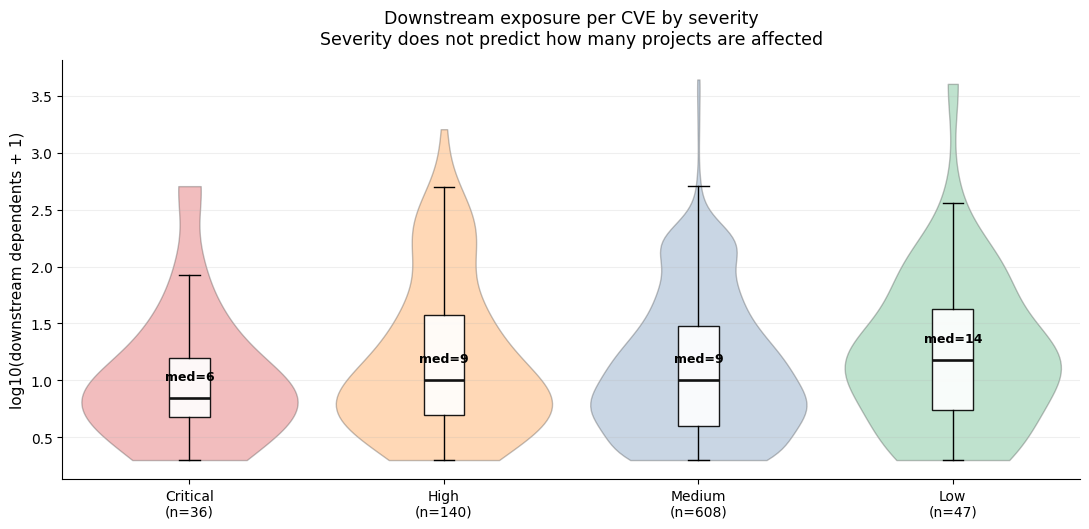

In [6]:
SEV_COLORS = {'Critical': '#d62728', 'High': '#ff7f0e', 'Medium': '#4c78a8',
              'Low': '#2ca25f', 'Unknown': '#8c8c8c'}
present = [s for s in SEV_ORDER if blast.severity.eq(s).sum() >= 5]

fig, ax = plt.subplots(figsize=(11, 5.4))
data = [np.log10(blast.loc[blast.severity.eq(s), 'dependents'] + 1) for s in present]
parts = ax.violinplot(data, showmedians=False, showextrema=False, widths=0.85)
for body, s in zip(parts['bodies'], present):
    body.set_facecolor(SEV_COLORS[s]); body.set_alpha(0.30); body.set_edgecolor('#333333')

bp = ax.boxplot(data, widths=0.16, patch_artist=True, showfliers=False,
                medianprops={'color': '#111111', 'linewidth': 1.9})
for patch in bp['boxes']:
    patch.set_facecolor('white'); patch.set_alpha(0.9)

for i, s in enumerate(present, 1):
    v = blast.loc[blast.severity.eq(s), 'dependents']
    ax.text(i, np.log10(v.median() + 1) + 0.16, f'med={v.median():.0f}',
            ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(range(1, len(present) + 1))
ax.set_xticklabels([f'{s}\n(n={blast.severity.eq(s).sum()})' for s in present], fontsize=10)
ax.set_ylabel('log10(downstream dependents + 1)', fontsize=11)
ax.set_title('Downstream exposure per CVE by severity\n'
             'Severity does not predict how many projects are affected', fontsize=12.5, pad=12)
ax.grid(axis='y', alpha=0.2)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / 'F1_breadth_by_severity.png', dpi=200, bbox_inches='tight')
plt.show()

---
## F2 — Lorenz curve of downstream exposure

The diagonal is perfect equality — every CVE affecting the same number of projects. The gap
between the diagonal and the curve is the Gini. Save this figure's data: notebook 05 overlays
the burden curve on it, and the difference between the two is the finding.

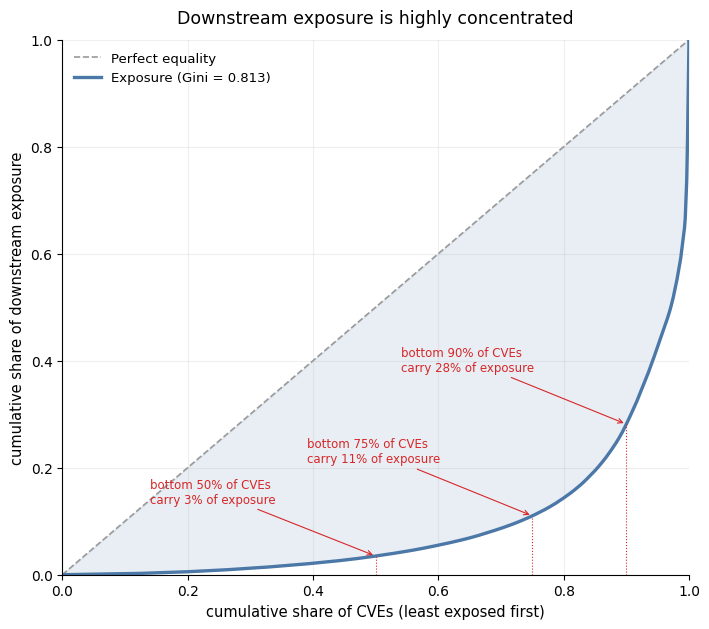

In [7]:
frac, cum = lorenz(blast.dependents.values)

fig, ax = plt.subplots(figsize=(7.2, 6.4))
ax.plot([0, 1], [0, 1], color='#999999', linestyle='--', linewidth=1.2, label='Perfect equality')
ax.plot(frac, cum, color='#4c78a8', linewidth=2.4, label=f'Exposure (Gini = {g:.3f})')
ax.fill_between(frac, cum, frac, color='#4c78a8', alpha=0.12)

for q in [0.5, 0.75, 0.9]:
    y = np.interp(q, frac, cum)
    ax.plot([q, q], [0, y], color='#d62728', linewidth=0.8, linestyle=':')
    ax.annotate(f'bottom {q:.0%} of CVEs\ncarry {y:.0%} of exposure',
                xy=(q, y), xytext=(q - 0.36, y + 0.10), fontsize=8.5, color='#d62728',
                arrowprops={'arrowstyle': '->', 'color': '#d62728', 'linewidth': 0.8})

ax.set_xlabel('cumulative share of CVEs (least exposed first)', fontsize=10.5)
ax.set_ylabel('cumulative share of downstream exposure', fontsize=10.5)
ax.set_title('Downstream exposure is highly concentrated', fontsize=12.5, pad=12)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(frameon=False, fontsize=9.5, loc='upper left')
ax.grid(alpha=0.2)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / 'F2_lorenz_exposure.png', dpi=200, bbox_inches='tight')
plt.show()

pd.DataFrame({'cum_share_cves': frac, 'cum_share_exposure': cum}).to_csv(
    OUT / 'F2_lorenz_exposure_data.csv', index=False)

---
## Model — what predicts blast radius?

Counts, heavily over-dispersed (mean far above median), so a **negative binomial** is the
right family — Poisson would badly understate the standard errors.

`statsmodels` is not installed, so the NB is fitted by maximum likelihood directly and
confidence intervals come from a **cluster bootstrap over upstream artifacts**. CVEs in the
same upstream library share a dependent base, so they are not independent observations.

In [8]:
model_df = blast.dropna(subset=['dependents', 'severity', 'rq1_reporting',
                                'stars_count_at_commit', 'commits_count_at_commit']).copy()
model_df['is_transparent'] = model_df.rq1_reporting.eq('Transparent').astype(int)
model_df['sev_high'] = model_df.severity.isin(['Critical', 'High']).astype(int)
model_df['log_stars'] = np.log1p(model_df.stars_count_at_commit)
model_df['log_commits'] = np.log1p(model_df.commits_count_at_commit)

FEATURES = ['is_transparent', 'sev_high', 'log_stars', 'log_commits']

def nb_fit(X, y):
    X = np.column_stack([np.ones(len(X)), X])
    def nll(p):
        b, la = p[:-1], p[-1]
        mu = np.exp(np.clip(X @ b, -25, 25))
        r = np.exp(-la)
        return -np.sum(gammaln(y + r) - gammaln(r) - gammaln(y + 1)
                       + r * np.log(r / (r + mu)) + y * np.log(mu / (r + mu)))
    p0 = np.zeros(X.shape[1] + 1); p0[0] = np.log(max(y.mean(), 1e-3))
    res = minimize(nll, p0, method='BFGS', options={'maxiter': 800})
    return res.x[1:-1]

Xz = model_df[FEATURES].to_numpy(float)
Xm, Xs = Xz.mean(0), Xz.std(0); Xs[Xs == 0] = 1
Xz = (Xz - Xm) / Xs
y = model_df.dependents.to_numpy(float)

point = nb_fit(Xz, y)

clusters = model_df.upstream_GA.to_numpy()
uniq = np.unique(clusters)
idx = {c: np.where(clusters == c)[0] for c in uniq}
draws = []
for _ in range(400):
    picked = rng.choice(uniq, size=len(uniq), replace=True)
    rows_ = np.concatenate([idx[c] for c in picked])
    try:
        draws.append(nb_fit(Xz[rows_], y[rows_]))
    except Exception:
        continue
draws = np.array(draws)

nb_out = pd.DataFrame({
    'Predictor': FEATURES,
    'IRR': np.exp(point).round(3),
    'CI low': np.exp(np.percentile(draws, 2.5, axis=0)).round(3),
    'CI high': np.exp(np.percentile(draws, 97.5, axis=0)).round(3),
})
nb_out['Significant'] = np.where((nb_out['CI low'] > 1) | (nb_out['CI high'] < 1), 'yes', 'no')
display(nb_out)

print(f'n CVEs = {len(model_df)} | clusters (upstream artifacts) = {len(uniq)} | bootstraps = {len(draws)}')
print('IRR per 1 SD. IRR > 1 means more downstream dependents.')

,Predictor,IRR,CI low,CI high,Significant
0,is_transparent,1.004,0.752,1.317,no
1,sev_high,1.141,0.874,1.369,no
2,log_stars,1.858,1.334,2.228,yes
3,log_commits,0.569,0.406,0.894,yes


n CVEs = 825 | clusters (upstream artifacts) = 374 | bootstraps = 400
IRR per 1 SD. IRR > 1 means more downstream dependents.


---
## Analysis set vs full universe

The timing analysis in notebooks 04-06 runs on the 191 CVEs with observed, dated mitigations.
This compares their blast radius to the CVEs left out, so the scope condition is explicit.

Established in `T10`: covered CVEs have roughly 9x the dependents of uncovered ones. That is
a scope statement, not a flaw — but it must appear in the paper.

In [9]:
blast['in_analysis'] = blast.CVE_ID.isin(set(master.CVE))
cmp_rows = []
for lab, sub in [('In timing analysis (191)', blast[blast.in_analysis]),
                 ('Not in timing analysis', blast[~blast.in_analysis])]:
    v = sub.dependents
    cmp_rows.append({'Set': lab, 'CVEs': len(sub), 'Median dependents': int(v.median()),
                     'IQR': f'[{v.quantile(.25):.0f}, {v.quantile(.75):.0f}]',
                     'Total pairs': int(v.sum()),
                     '% of all exposure': round(100 * v.sum() / TOTAL, 1)})
scope = pd.DataFrame(cmp_rows)
display(scope)

_, p = mannwhitneyu(blast.loc[blast.in_analysis, 'dependents'],
                    blast.loc[~blast.in_analysis, 'dependents'])
print(f'Mann-Whitney p = {p:.6f}')
print()
print('Wording for the paper: RQ2 timing results describe widely-depended-upon')
print('vulnerabilities, not the median CVE.')

,Set,CVEs,Median dependents,IQR,Total pairs,% of all exposure
0,In timing analysis (191),191,47,"[24, 134]",14909,33.5
1,Not in timing analysis,641,6,"[3, 13]",29541,66.5


Mann-Whitney p = 0.000000

Wording for the paper: RQ2 timing results describe widely-depended-upon
vulnerabilities, not the median CVE.


---
## Save

In [10]:
T1.to_csv(OUT / 'T1_exposure_breadth.csv', index=False)
T2.to_csv(OUT / 'T2_top_cves_by_exposure.csv', index=False)
nb_out.to_csv(OUT / 'T1b_breadth_model.csv', index=False)
scope.to_csv(OUT / 'T1c_analysis_set_scope.csv', index=False)
blast.to_csv(OUT / 'rq2_blast_radius_per_cve.csv', index=False)

for f in ['T1_exposure_breadth.csv', 'T2_top_cves_by_exposure.csv', 'T1b_breadth_model.csv',
          'T1c_analysis_set_scope.csv', 'rq2_blast_radius_per_cve.csv',
          'F1_breadth_by_severity.png', 'F2_lorenz_exposure.png', 'F2_lorenz_exposure_data.csv']:
    print(f)

T1_exposure_breadth.csv
T2_top_cves_by_exposure.csv
T1b_breadth_model.csv
T1c_analysis_set_scope.csv
rq2_blast_radius_per_cve.csv
F1_breadth_by_severity.png
F2_lorenz_exposure.png
F2_lorenz_exposure_data.csv
